Fundamentals of Deep Learning Models

# Lab 10-1: 3D Volumetric Rendering with NeRF
## Exercise: Minimal implementation of volumetric rendering as described in NeRF

This exercise implements a simplified (coarse-network-only) version of the **Neural Radiance Fields (NeRF)** pipeline (Sections 10.5–10.8) using the `tiny_nerf_data` dataset. The code structure is adapted from the [Keras NeRF example](https://keras.io/examples/vision/nerf/) (Apache 2.0 License).

## Objective

This exercise presents a minimal implementation of the coarse-stage rendering described in the paper [**NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis**](https://arxiv.org/abs/2003.08934) by Mildenhall et al. (2020). NeRF synthesizes novel views of a scene by modeling the volumetric radiance field through an MLP that maps 3D positions and viewing directions to color and density (Section 10.1–10.2).

**Note:** This implementation uses only the coarse network (no hierarchical sampling with a fine network) and uses 64 hidden units instead of 256, as described in the textbook (Section 10.8), in order to keep training time manageable.

### Setup

In [1]:
RunningInCOLAB = 'google.colab' in str(get_ipython())

if RunningInCOLAB:
    from tqdm.notebook import tqdm
else:
    from tqdm import tqdm

In [2]:
import os
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 1.26.4
TensorFlow version: 2.16.1
Keras version: 3.4.1
Matplotlib version: 3.9.1
Num GPUs Available:  1


In [3]:
import glob
import imageio.v3 as iio
import base64
from IPython import display

In [4]:
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
def show_gif(fname):
    with open(fname, 'rb') as fd:
        b64 = base64.b64encode(fd.read()).decode('ascii')
    return display.HTML(f'<img src="data:image/gif;base64,{b64}" />')

def show_video(video_path, video_width = 320):
  video_file = open(video_path, "r+b").read()
  video_url = f"data:video/mp4;base64,{base64.b64encode(video_file).decode()}"
  return display.HTML(f"""<video width={video_width} controls><source src="{video_url}"></video>""")


### Introduction

To build intuition, consider the following two questions:

- *Could we construct a function that takes a pixel position in an image and returns the color at that position?*
- *Could a neural network approximate such a function?*

As discussed in Section 10.1, the Fourier epicycle drawing illustrates how complex 2D curves can be decomposed and reconstructed using frequency components. The corresponding Fourier series is:

$$ f(t) = \sum^{N}_{n=-N} C_n e^{-i 2 \pi {n \over{T}} t} $$

In the above equation, every $t$ maps to a single point in the drawing. The second question asks whether a neural network — a universal function approximator (Section 10.1) — can learn such a mapping.

The network would effectively *memorize* (overfit on) the image, encoding the entire scene in its weights. Given any query position, it would reconstruct the corresponding color.

Can we extend this idea to learn a 3D volumetric scene? NeRF achieves this by learning a continuous radiance field from a sparse set of posed 2D images, without explicit voxel representations (Section 10.2). The network models the volumetric scene function, mapping 3D spatial coordinates and viewing directions to color and density, and generates novel views through volume rendering (Sections 10.5–10.8).

### Camera Data Format

A camera defines a mapping between the 3D world and a 2D image (Section 10.3). Using the camera matrix $\mathbf{M}_c$ in homogeneous coordinates (Eq. 10.3):

$$ \lambda \mathbf{p}_p = \mathbf{M}_c \mathbf{p}_w = \mathbf{W}_s \mathbf{K}_i \mathbf{R}_e \mathbf{T}_e \mathbf{p}_w $$

where $\mathbf{p}_w$ is a 3D world point, $\mathbf{p}_p$ is the corresponding pixel coordinate, $\mathbf{R}_e$ and $\mathbf{T}_e$ are the extrinsic parameters (rotation and translation), and $\mathbf{K}_i$ contains the intrinsic parameters (Eqs. 10.1–10.3).

In practice, the camera pose is often provided as a 4×4 matrix that combines rotation and translation, along with the focal length as a separate scalar.

**Note:** Different datasets adopt different coordinate conventions. The `tiny_nerf_data` used here follows the OpenGL convention `[right, up, backward]`, whereas COLMAP uses `[right, down, forward]`. Consistency is essential (Section 10.3).

### Download and load the data

In this exercise, we use `tiny_nerf_data` from the NeRF authors' site at UCSD. The `npz` file contains images, camera poses, and a focal length. The images are captured from multiple camera angles.

<font color='red'>**NOTE: The camera matrix in `tiny_nerf_data.npz` is a camera-to-world (C2W) matrix.**</font>

This means the pose matrix transforms camera-coordinate points to world coordinates (the inverse of the extrinsic parameters $\mathbf{R}_e \mathbf{T}_e$ in Eq. 10.9). Each 4×4 pose matrix has the form:

$$ \begin{bmatrix} \mathbf{X}_w \\ 1 \end{bmatrix} =
\begin{bmatrix} \mathbf{R}^T & \mathbf{o}_c \\ \mathbf{0}^T & 1 \end{bmatrix}
\begin{bmatrix} \mathbf{X}_c \\ 1 \end{bmatrix} $$

where $\mathbf{R}^T$ is the transpose of the rotation matrix and $\mathbf{o}_c$ is the camera origin in world coordinates (Section 10.3).

The focal length is provided as a separate scalar field.

12727482/12727482 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


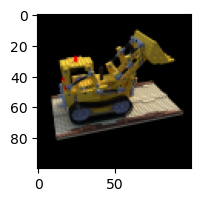

[[-3.0069298e-01  4.7792530e-01 -8.2533085e-01 -3.3270154e+00]
 [-9.5372099e-01 -1.5068220e-01  2.6021361e-01  1.0489547e+00]
 [ 7.4505806e-09  8.6537987e-01  5.0111634e-01  2.0200648e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]
<class 'numpy.ndarray'> 138.88887889922103


In [6]:
# Download the data if it does not already exist.
url = (
    'http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz'
)
data = keras.utils.get_file(origin=url)

data = np.load(data)
images = data['images']
im_shape = images.shape
(NUM_IMAGES, H, W, _) = images.shape
(poses, FOCAL) = (data['poses'], data['focal'])

# Plot a random image from the dataset for visualization.
img_idx = np.random.randint(low=0, high=NUM_IMAGES)
plt.figure(figsize=(2,2))
plt.imshow(images[img_idx])
plt.show()
print(poses[img_idx])
print(type(FOCAL), FOCAL)

### Data pipeline

Now that you've understood the notion of camera matrix
and the mapping from a 3D scene to 2D images,
let's talk about the inverse mapping, i.e. from 2D image to the 3D scene.

We'll need to talk about volumetric rendering with ray casting and tracing,
which are common computer graphics techniques.
This section will help you get to speed with these techniques.


### Ray casting and sampling

Consider an image with $H \times W$ pixels. For each pixel, a ray is cast from the camera origin through the pixel into the scene (Section 10.5). A ray is parameterized as (Eq. 10.25):

$$ \mathbf{r}(t) = \mathbf{o}_r + t \mathbf{d}_r $$

where $\mathbf{o}_r$ is the camera origin and $\mathbf{d}_r$ is the direction vector. Along each ray, $N$ sample points are selected using stratified sampling (Section 10.7). Each sample has a 3D position and a viewing direction, which serve as inputs to the NeRF network.

Uniform noise is added to the sampling to approximate a continuous distribution, following the stratified sampling strategy described in Section 10.7.

In [7]:
# Initialize global variables.
AUTO = tf.data.AUTOTUNE
BATCH_SIZE = 2
NUM_SAMPLES = 32
POS_ENCODE_DIMS = 16
POS_ENCODE_DIRS = 8
EPOCHS = 100

### Practice: Change of coordinates

**From image coordinates (OpenCV: `[row(down), col(right)]`) to camera coordinates (OpenGL: `[x(right), y(up), z(backward)]`):**

As described in Section 10.4, the virtual image plane in NeRF is placed at unit depth ($z = -1$). The pixel-to-camera coordinate transformation (Eq. 10.24) maps each pixel $(u, v)$ to a normalized camera-coordinate direction by centering the image at the origin and dividing by the focal length.

In [ ]:
def print_a(h,w,a):
    for j in range(h):
        for i in range(w):
            print(f'{str(a[w*j+i].numpy()):8}', end='')
        print('')
    print('')

def print_b(h,w,a):
    for j in range(h):
        for i in range(w):
            print('[', end='')
            for k in range(3):
                print(f'{a[w*j+i][k].numpy():>5.1f}', end='')
            print('] ', end='')
        print('')
    print('')


# option for tf.meshgrid()
# indexing='xy': increase x first, indexing='ij': increase j first

t_width = 6; t_height = 4; t_focal = 2.0

### START CODE HERE ###

# Build pixel grid: (u, v) indices for all pixels (Eq. 10.24 input)
x0, y0 = tf.meshgrid(...)

###  END CODE HERE  ###

c1 = tf.stack([x0,y0], axis=-1)
c2 = tf.reshape(c1, (-1,2))

print('Serialized Dimensions:', c1.shape, '->', c2.shape,'\n')

print('HW to XY:')
print_a(t_height, t_width, c2)

### START CODE HERE ###

# Center the image at origin: x_i = u - W/2 (Eq. 10.24, first row)
x1 = None
# Flip y-axis (image y-down -> camera y-up): y_i = -(v - H/2) (Eq. 10.24, second row)
y1 = None
# Set z = -focal for the virtual image plane (Section 10.3)
z1 = None

###  END CODE HERE  ###

c1 = tf.stack([x1,y1,z1], axis=-1)
c2 = tf.reshape(c1, (-1,3))

print('Serialized Dimensions:', c1.shape, '->', c2.shape,'\n')

print('Center Aligned Camera Coordinates:')
print_b(t_height, t_width, c2)

print('Normalized Coordinates:')

### START CODE HERE ###

# Normalize by focal length: place image plane at z = -1 (Section 10.4, Eq. 10.24)
c3 = None

###  END CODE HERE  ###

print_b(t_height, t_width, c3)

Serialized Dimensions: (4, 6, 2) -> (24, 2) 

HW to XY:
[0. 0.] [1. 0.] [2. 0.] [3. 0.] [4. 0.] [5. 0.] 
[0. 1.] [1. 1.] [2. 1.] [3. 1.] [4. 1.] [5. 1.] 
[0. 2.] [1. 2.] [2. 2.] [3. 2.] [4. 2.] [5. 2.] 
[0. 3.] [1. 3.] [2. 3.] [3. 3.] [4. 3.] [5. 3.] 

Serialized Dimensions: (4, 6, 3) -> (24, 3) 

Center Aligned Camera Coordinates:
[ -3.0  2.0 -2.0] [ -2.0  2.0 -2.0] [ -1.0  2.0 -2.0] [  0.0  2.0 -2.0] [  1.0  2.0 -2.0] [  2.0  2.0 -2.0] 
[ -3.0  1.0 -2.0] [ -2.0  1.0 -2.0] [ -1.0  1.0 -2.0] [  0.0  1.0 -2.0] [  1.0  1.0 -2.0] [  2.0  1.0 -2.0] 
[ -3.0 -0.0 -2.0] [ -2.0 -0.0 -2.0] [ -1.0 -0.0 -2.0] [  0.0 -0.0 -2.0] [  1.0 -0.0 -2.0] [  2.0 -0.0 -2.0] 
[ -3.0 -1.0 -2.0] [ -2.0 -1.0 -2.0] [ -1.0 -1.0 -2.0] [  0.0 -1.0 -2.0] [  1.0 -1.0 -2.0] [  2.0 -1.0 -2.0] 

Normalized Coordinates:
[ -1.5  1.0 -1.0] [ -1.0  1.0 -1.0] [ -0.5  1.0 -1.0] [  0.0  1.0 -1.0] [  0.5  1.0 -1.0] [  1.0  1.0 -1.0] 
[ -1.5  0.5 -1.0] [ -1.0  0.5 -1.0] [ -0.5  0.5 -1.0] [  0.0  0.5 -1.0] [  0.5  0.5 -1.0] [  1.0

**Expected Outputs**

```
Serialized Dimensions: (4, 6, 2) -> (24, 2)

HW to XY:
[0. 0.] [1. 0.] [2. 0.] [3. 0.] [4. 0.] [5. 0.]
[0. 1.] [1. 1.] [2. 1.] [3. 1.] [4. 1.] [5. 1.]
[0. 2.] [1. 2.] [2. 2.] [3. 2.] [4. 2.] [5. 2.]
[0. 3.] [1. 3.] [2. 3.] [3. 3.] [4. 3.] [5. 3.]

Serialized Dimensions: (4, 6, 3) -> (24, 3)

Center Aligned Camera Coordinates:
[-3.0  2.0 -2.0] [-2.0  2.0 -2.0] [-1.0  2.0 -2.0] [ 0.0  2.0 -2.0] [ 1.0  2.0 -2.0] [ 2.0  2.0 -2.0]
[-3.0  1.0 -2.0] [-2.0  1.0 -2.0] [-1.0  1.0 -2.0] [ 0.0  1.0 -2.0] [ 1.0  1.0 -2.0] [ 2.0  1.0 -2.0]
[-3.0 -0.0 -2.0] [-2.0 -0.0 -2.0] [-1.0 -0.0 -2.0] [ 0.0 -0.0 -2.0] [ 1.0 -0.0 -2.0] [ 2.0 -0.0 -2.0]
[-3.0 -1.0 -2.0] [-2.0 -1.0 -2.0] [-1.0 -1.0 -2.0] [ 0.0 -1.0 -2.0] [ 1.0 -1.0 -2.0] [ 2.0 -1.0 -2.0]

Normalized Coordinates:
[-1.5  1.0 -1.0] [-1.0  1.0 -1.0] [-0.5  1.0 -1.0] [ 0.0  1.0 -1.0] [ 0.5  1.0 -1.0] [ 1.0  1.0 -1.0]
[-1.5  0.5 -1.0] [-1.0  0.5 -1.0] [-0.5  0.5 -1.0] [ 0.0  0.5 -1.0] [ 0.5  0.5 -1.0] [ 1.0  0.5 -1.0]
[-1.5 -0.0 -1.0] [-1.0 -0.0 -1.0] [-0.5 -0.0 -1.0] [ 0.0 -0.0 -1.0] [ 0.5 -0.0 -1.0] [ 1.0 -0.0 -1.0]
[-1.5 -0.5 -1.0] [-1.0 -0.5 -1.0] [-0.5 -0.5 -1.0] [ 0.0 -0.5 -1.0] [ 0.5 -0.5 -1.0] [ 1.0 -0.5 -1.0]
```

### Change of coordinates

**From image coordinates to world coordinates:**

The `get_rays` function constructs world-space rays for each pixel. It applies the inverse projection (Eq. 10.24) to obtain camera-coordinate directions, then transforms them to world coordinates using the C2W pose matrix (Eq. 10.33–10.34):

$$ \mathbf{d}_w = \mathbf{R}_e^T \mathbf{d}_c, \quad \mathbf{r}_w(t) = \mathbf{o}_c + t \mathbf{d}_w $$

In [ ]:
def get_rays(height, width, focal, pose):
    '''Computes origin point and direction vector of rays.

    Args:
        height: Height of the image.
        width: Width of the image.
        focal: The focal length between the images and the camera.
        pose: The pose matrix of the camera (C2W, 3x4 or 4x4).

    Returns:
        Tuple of origin point and direction vector for rays.
    '''

    ### START CODE HERE ###

    # Build pixel grid: (u, v) for all pixels
    x, y = tf.meshgrid(...)

    # Apply inverse projection: pixel -> normalized camera coords (Eq. 10.24)
    normalized_x = None
    normalized_y = None

    # Build direction vectors in camera coords: d_c = [x_i, -y_i, -1] (Section 10.4)
    directions = None

    # Extract rotation matrix R^T and camera origin o_c from C2W pose
    camera_matrix = None
    camera_origin = None

    # Transform directions to world coords: d_w = R^T * d_c (Eq. 10.33)
    transformed_dirs = None
    camera_dirs = None
    ray_directions = None

    # Broadcast camera origin to all rays: o_c (Eq. 10.34)
    ray_origins = None

    ###  END CODE HERE  ###

    # Return the origins and directions.
    return (ray_origins, ray_directions)

In [10]:
tf.random.set_seed(0)
a, b = get_rays(4.,6.,2.,tf.random.uniform((3,4)))
c = a - b
d = tf.convert_to_tensor([[[1.3280444 , 1.3085382 , 2.2919614 ], [1.1820569 , 1.1002009 , 1.9435939 ], [1.0360694 , 0.89186364, 1.5952263 ],
                           [0.89008176, 0.6835264 , 1.2468587 ], [0.7440942 , 0.4751891 , 0.89849114], [0.5981066 , 0.2668519 , 0.5501236 ]],
                          [[1.4313277 , 1.7124522 , 2.354648  ], [1.2853401 , 1.5041149 , 2.0062807 ], [1.1393526 , 1.2957776 , 1.6579131 ],
                           [0.993365  , 1.0874404 , 1.3095455 ], [0.8473774 , 0.8791031 , 0.96117795], [0.70138985, 0.6707659 , 0.6128104 ]],
                          [[1.534611  , 2.116366  , 2.417335  ], [1.3886234 , 1.9080288 , 2.0689673 ], [1.2426357 , 1.6996915 , 1.7205999 ],
                           [1.0966482 , 1.4913543 , 1.3722323 ], [0.95066065, 1.2830172 , 1.0238647 ], [0.8046731 , 1.0746799 , 0.6754972 ]],
                          [[1.6378942 , 2.52028   , 2.480022  ], [1.4919066 , 2.3119428 , 2.1316543 ], [1.345919  , 2.1036057 , 1.7832867 ],
                           [1.1999314 , 1.8952683 , 1.4349191 ], [1.0539439 , 1.6869311 , 1.0865515 ], [0.9079563 , 1.4785938 , 0.738184  ]]])
print('Test passed.') if np.allclose(c,d) else print('Test failed.')

Test passed.


## Positional Encoding

NeRF maps each scalar coordinate to a higher-dimensional feature vector using sinusoidal positional encoding (Eq. 10.35):

$$ \gamma_L(p) = \left( \sin(2^{0}\pi p), \cos(2^{0}\pi p), \ldots, \sin(2^{L-1}\pi p), \cos(2^{L-1}\pi p) \right) $$

**Implementation note:** In this implementation, $\pi$ is omitted (i.e., set to 1) for simplicity, which is a common convention in practical NeRF implementations. The network can compensate for this scaling difference during training.

In [ ]:
def encode_position(x, enc_len=POS_ENCODE_DIMS, include_x=True):
    '''Encodes the position into its corresponding Fourier feature.

    Args:
        x: The input coordinate.
        enc_len: Number of frequency levels L.
        include_x: Whether to concatenate the original coordinate.

    Returns:
        Fourier features tensors of the position.
    '''
    positions = [x] if include_x else []
    for i in range(enc_len):

        ### START CODE HERE ###

        # Apply sin and cos at frequency 2^i (Eq. 10.35, with pi=1)
        for fn in [tf.sin, tf.cos]:
            positions.append(...)

        ###  END CODE HERE  ###

    return tf.concat(positions, axis=-1)

In [12]:
a = encode_position(tf.convert_to_tensor([[1.,2.,3.],[4.,5.,6.]]), 2, True)
a

<tf.Tensor: shape=(2, 15), dtype=float32, numpy=
array([[ 1.        ,  2.        ,  3.        ,  0.841471  ,  0.90929747,
         0.14112   ,  0.5403023 , -0.4161468 , -0.9899925 ,  0.90929747,
        -0.7568025 , -0.2794155 , -0.4161468 , -0.65364367,  0.96017027],
       [ 4.        ,  5.        ,  6.        , -0.7568025 , -0.9589243 ,
        -0.2794155 , -0.65364367,  0.28366217,  0.96017027,  0.98935825,
        -0.54402107, -0.53657293, -0.14550003, -0.8390716 ,  0.84385395]],
      dtype=float32)>

**Expected Output**
```
<tf.Tensor: shape=(2, 15), dtype=float32, numpy=
array([[ 1.        ,  2.        ,  3.        ,  0.841471  ,  0.90929747,
         0.14112   ,  0.5403023 , -0.4161468 , -0.9899925 ,  0.90929747,
        -0.7568025 , -0.2794155 , -0.4161468 , -0.65364367,  0.96017027],
       [ 4.        ,  5.        ,  6.        , -0.7568025 , -0.9589243 ,
        -0.2794155 , -0.65364367,  0.28366217,  0.96017027,  0.98935825,
        -0.54402107, -0.53657293, -0.14550003, -0.8390716 ,  0.84385395]],
      dtype=float32)>
```

## Making Rendering Parameters

Volume rendering in NeRF requires sampling points along each ray and predicting density and color at each sample (Section 10.5). The function `render_flat_rays` generates 3D sample coordinates by dividing the interval $[t_n, t_f]$ into `num_samples` segments using stratified sampling (Section 10.7), then applies positional encoding to both positions and directions.

In [ ]:
def get_t_val(ray_shape, near, far, num_samples, rand=False):

    ### START CODE HERE ###

    # Create uniform sample positions between near and far bounds (Section 10.7)
    t_vals = None                                       # use tf.linspace()
    shape = list(ray_shape[:-1]) + [num_samples]        # make the final output shape
    if rand:
        # Add stratified noise: uniform in [0, delta] where delta = (far-near)/N
        noise = None
        t_vals = t_vals + noise
    else:
        t_vals = tf.broadcast_to(t_vals, shape)         # broadcast to the output shape

    ###  END CODE HERE  ###

    return t_vals

In [14]:
tf.random.set_seed(0)
a = get_t_val((2,2), 2., 4., 3, rand=True)
a

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[2.1946502, 3.137711 , 4.356927 ],
       [2.3741717, 3.277783 , 4.538552 ]], dtype=float32)>

**Expected Output**
```
<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[2.1946502, 3.137711 , 4.356927 ],
       [2.3741717, 3.277783 , 4.538552 ]], dtype=float32)>
```

In [15]:
def render_flat_rays(ray_origins, ray_directions, near, far, num_samples, rand=False):
    '''Renders the rays and flattens it.

    Args:
        ray_origins: The origin points for rays.
        ray_directions: The direction unit vectors for the rays.
        near: The near bound of the volumetric scene.
        far: The far bound of the volumetric scene.
        num_samples: Number of sample points in a ray.
        rand: Choice for randomising the sampling strategy.

    Returns:
       Tuple of flattened rays and sample points on each rays.
    '''
    # Compute 3D query points.
    # Equation: r(t) = o+td -> Building the 't' here.

    ray_shape = ray_origins.shape
    t_vals = get_t_val(ray_shape, near, far, num_samples, rand)

    # Equation: r(t) = o + td -> Building the 'r' here.
    ray_dirs = ray_directions[..., None, :] * t_vals[..., None]
    rays = ray_origins[..., None, :] + ray_dirs
    rays_flat = tf.reshape(rays, [-1, 3])
    rays_flat = encode_position(rays_flat, enc_len=POS_ENCODE_DIMS)
    dirs_flat = tf.reshape(ray_dirs, [-1, 3])
    dirs_flat = encode_position(dirs_flat, enc_len=POS_ENCODE_DIRS)
    return (rays_flat, dirs_flat, t_vals)

## Building Dataset Pipeline for Training

In [16]:
def map_fn(pose):
    '''Maps individual pose to flattened rays and sample points.

    Args:
        pose: The pose matrix of the camera.

    Returns:
        Tuple of flattened rays and sample points corresponding to the
        camera pose.
    '''
    ray_origins, ray_directions = get_rays(height=H, width=W, focal=FOCAL, pose=pose)
    rays_flat, dirs_flat, t_vals = render_flat_rays(
        ray_origins=ray_origins,
        ray_directions=ray_directions,
        near=2.0,
        far=6.0,
        num_samples=NUM_SAMPLES,
        rand=True,
    )
    rays_flat = tf.concat([rays_flat, dirs_flat], axis=-1)
    return (rays_flat, t_vals)


# Create the training split.
split_index = int(NUM_IMAGES * 0.8)

# Split the images into training and validation.
train_images = images[:split_index]
val_images = images[split_index:]

# Split the poses into training and validation.
train_poses = poses[:split_index]
val_poses = poses[split_index:]

# Make the training pipeline.
train_img_ds = tf.data.Dataset.from_tensor_slices(train_images)
train_pose_ds = tf.data.Dataset.from_tensor_slices(train_poses)
train_ray_ds = train_pose_ds.map(map_fn, num_parallel_calls=AUTO)
training_ds = tf.data.Dataset.zip((train_img_ds, train_ray_ds))
train_ds = (
    training_ds.shuffle(BATCH_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True, num_parallel_calls=AUTO)
    .prefetch(AUTO)
)

# Make the validation pipeline.
val_img_ds = tf.data.Dataset.from_tensor_slices(val_images)
val_pose_ds = tf.data.Dataset.from_tensor_slices(val_poses)
val_ray_ds = val_pose_ds.map(map_fn, num_parallel_calls=AUTO)
validation_ds = tf.data.Dataset.zip((val_img_ds, val_ray_ds))
val_ds = (
    validation_ds.shuffle(BATCH_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True, num_parallel_calls=AUTO)
    .prefetch(AUTO)
)

## NeRF model

The NeRF model is a multi-layer perceptron (MLP) with ReLU activations (Section 10.8). The architecture processes positionally encoded 3D coordinates through several fully connected layers with a skip connection, then branches into a density output and a view-dependent color output.

As described in Section 10.8, the original NeRF uses 8 layers with 256 units, a skip connection at the 5th layer, and separate branches for density ($\sigma$, via ReLU) and color ($\mathbf{c}$, via sigmoid). Here we use **64 units** instead of 256 for faster training.

The density depends only on spatial position, while the color also depends on the viewing direction (Section 10.8). The direction input is concatenated with an intermediate feature vector and processed through additional layers.

In [ ]:
NUM_UNITS = 64

def get_nerf_model(num_layers, num_pos, skip_layer=4):
    '''Generates the NeRF neural network.

    Args:
        num_layers: The number of MLP layers.
        num_pos: The number of sample points (determines input shape).
        skip_layer: Layer interval for skip connections (Section 10.8).

    Returns:
        The `keras` model.
    '''
    len_pe_x = 2*3*POS_ENCODE_DIMS+3    # positional encoding dim for position
    len_pe_d = 2*3*POS_ENCODE_DIRS+3    # positional encoding dim for direction

    inputs = keras.Input(shape=(num_pos, len_pe_x + len_pe_d))

    # Split input into position encoding and direction encoding
    x = inputs[..., :len_pe_x]
    d = inputs[..., len_pe_x:]

    ### START CODE HERE ###

    # Save position input for skip connection (Section 10.8)
    s = None

    # Build MLP layers with skip connections (Section 10.8, Figure 10.9)
    for i in range(num_layers):
        x = None
        if i % skip_layer == 0 and i > 0:
            # Skip connection: concatenate original position input
            x = None
    # Density output: sigma via linear layer (ReLU applied later) (Section 10.8)
    dens = None

    # Color branch: concatenate direction and process (Section 10.8)
    x = keras.layers.concatenate(...)
    x = None
    x = None

    # RGB output: 3 color channels (sigmoid applied in render_rgb_depth)
    rgbs = None

    ###  END CODE HERE  ###

    outputs = keras.layers.concatenate([rgbs, dens], axis=-1)

    return keras.Model(inputs=inputs, outputs=outputs)

In [18]:
keras.utils.set_random_seed(42)
temp_model = get_nerf_model(num_layers=4, num_pos= 6*4*3, skip_layer=2)
temp_model.summary()
a = temp_model(tf.random.uniform((2, 72, 150)))
print('\nTest Output:\n', a[1,10:12])
del temp_model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 72, 150)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 72, 99)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 72, 64)    │      6,400 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 72, 64)    │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 72, 64)    │      4,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72, 163)   │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 72, 64)    │     10,496 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 72, 51)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 72, 115)   │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 72, 64)    │      7,424 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 72, 32)    │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 72, 3)     │         99 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 72, 1)     │         65 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 72, 4)     │          0 │ dense_7[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,884 (136.27 KB)

 Trainable params: 34,884 (136.27 KB)

 Non-trainable params: 0 (0.00 B)


Test Output:
 tf.Tensor(
[[ 0.29003748  0.17549187  0.19796343  0.29375514]
 [ 0.52255434  0.13061321  0.00749597 -0.3299224 ]], shape=(2, 4), dtype=float32)


**Expected Test Output**
```
 tf.Tensor(
[[ 0.28981906  0.17546266  0.1980237   0.2937552 ]
 [ 0.5225388   0.13040824  0.00763708 -0.32992253]], shape=(2, 4), dtype=float32)
```

In [ ]:
IN_SHAPE = (BATCH_SIZE, H, W, NUM_SAMPLES)

def render_rgb_depth(model, rays_flat, t_vals, i_shape=IN_SHAPE, train=True):
    '''Generates the RGB image and depth map from model prediction.

    Args:
        model: The MLP model that predicts rgb and volume density.
        rays_flat: The flattened rays (input to the NeRF model).
        t_vals: The sample points along the rays.
        i_shape: (BATCH_SIZE, H, W, NUM_SAMPLES)
        train: Whether the model is in the training or testing phase.

    Returns:
        Tuple of rgb image and depth map.
    '''
    # Get the predictions from the nerf model and reshape it to image form.
    if train:
        predictions = model(rays_flat)
    else:
        predictions = model.predict(rays_flat, verbose=0)
    predictions = tf.reshape(predictions, shape=list(i_shape)+[4])

    ### START CODE HERE ###

    # Extract RGB and density predictions
    rgb = None
    # Apply ReLU to ensure non-negative density (Section 10.8)
    sigma_a = None

    # Compute inter-sample distances: delta_i = t_{i+1} - t_i (Eq. 10.28)
    delta = None
    # Pad last delta with large value (approximates infinity)
    delta = None
    # Compute opacity: alpha_i = 1 - exp(-sigma_i * delta_i) (Eq. 10.29)
    alpha = None

    # Compute transmittance: T_i = prod_{j<i} (1 - alpha_j) (Eq. 10.30)
    transmittance = None
    # Compute rendering weights: w_i = T_i * alpha_i (Eq. 10.28)
    weights = None

    ###  END CODE HERE  ###

    # Accumulate weighted colors: C(r) = sum_i w_i * c_i (Eq. 10.28)
    rgb = tf.reduce_sum(weights[..., None] * rgb, axis=-2)
    # Compute depth map as weighted sum of sample distances
    depth_map = tf.reduce_sum(weights * t_vals, axis=-1)

    return (rgb, depth_map)

In [20]:
keras.utils.set_random_seed(42)
temp_model = get_nerf_model(num_layers=4, num_pos= 6*4*3, skip_layer=2)

a, b = render_rgb_depth(temp_model, tf.random.uniform((2, 72, 150)), tf.random.uniform((2, 6, 4, 3)), (2, 6, 4, 3))

print('\nTest Output:\na.shape =', a.shape, '  a[0,0,0]=',a[0,0,0])
print('b.shape =', b.shape, '  b[0,0]=',b[0,0])
del temp_model


Test Output:
a.shape = (2, 6, 4, 3)   a[0,0,0]= tf.Tensor([-0.04935485 -0.03776446 -0.04689922], shape=(3,), dtype=float32)
b.shape = (2, 6, 4)   b[0,0]= tf.Tensor([-0.05545512  0.88259256  0.3395992   0.69734323], shape=(4,), dtype=float32)


**Expected Outputs**
```
Test Output:
a.shape = (2, 6, 4, 3)   a[0,0,0]= tf.Tensor([-0.04935366 -0.03776291 -0.04689954], shape=(3,), dtype=float32)
b.shape = (2, 6, 4)   b[0,0]= tf.Tensor([-0.05545512  0.88259256  0.3395992   0.69734323], shape=(4,), dtype=float32)
```

## Training

The training step is implemented as a custom `keras.Model` subclass. For each batch, the model renders pixel colors via volume rendering (Section 10.5, Eq. 10.28) and optimizes the MSE loss between rendered and ground-truth pixel colors (Eq. 10.38). The Adam optimizer is used as described in Section 10.8.

In [21]:
class NeRF(keras.Model):
    def __init__(self, nerf_model):
        super().__init__()
        self.nerf_model = nerf_model

    def compile(self, optimizer, loss_fn):
        super().compile()
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.loss_tracker = keras.metrics.Mean(name='loss')
        self.psnr_metric = keras.metrics.Mean(name='psnr')

    def train_step(self, inputs):
        # Get the images and the rays.
        (images, rays) = inputs
        (rays_flat, t_vals) = rays

        with tf.GradientTape() as tape:
            # Render pixel colors via volume rendering (Eq. 10.28)
            rgb, _ = render_rgb_depth(self.nerf_model, rays_flat, t_vals, IN_SHAPE)
            # Compute MSE loss (Eq. 10.38, coarse network only)
            loss = self.loss_fn(images, rgb)

        # Get the trainable variables.
        trainable_variables = self.nerf_model.trainable_variables

        # Compute gradients of the loss w.r.t. trainable variables.
        gradients = tape.gradient(loss, trainable_variables)

        # Apply the gradients and optimize the model.
        self.optimizer.apply_gradients(zip(gradients, trainable_variables))

        # Compute PSNR between reconstructed and source images.
        psnr = tf.image.psnr(images, rgb, max_val=1.0)

        # Update metrics
        self.loss_tracker.update_state(loss)
        self.psnr_metric.update_state(psnr)
        return {'loss': self.loss_tracker.result(), 'psnr': self.psnr_metric.result()}

    def test_step(self, inputs):
        # Get the images and the rays.
        (images, rays) = inputs
        (rays_flat, t_vals) = rays

        # Render pixel colors via volume rendering
        rgb, _ = render_rgb_depth(self.nerf_model, rays_flat, t_vals, IN_SHAPE)
        loss = self.loss_fn(images, rgb)

        # Compute PSNR
        psnr = tf.image.psnr(images, rgb, max_val=1.0)

        # Update metrics
        self.loss_tracker.update_state(loss)
        self.psnr_metric.update_state(psnr)
        return {'loss': self.loss_tracker.result(), 'psnr': self.psnr_metric.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.psnr_metric]

In [22]:
test_imgs, test_rays = next(iter(train_ds))
test_rays_flat, test_t_vals = test_rays

psnr_list = []

In [23]:
class TrainMonitor(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        psnr = logs['psnr']
        psnr_list.append(psnr)
        test_recons_images, depth_maps = render_rgb_depth(
            model=self.model.nerf_model,
            rays_flat=test_rays_flat,
            t_vals=test_t_vals,
            i_shape=IN_SHAPE,
            train=False,
        )

        # Plot the rgb, depth and the loss plot.
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))
        ax[0].imshow(keras.utils.array_to_img(test_recons_images[0]))
        ax[0].set_title(f'Predicted Image: {epoch:03d}')

        ax[1].imshow(keras.utils.array_to_img(depth_maps[0, ..., None]))
        ax[1].set_title(f'Depth Map: {epoch:03d}')

        ax[2].plot(psnr_list)
        ax[2].set_xticks(np.arange(0, epoch + 1, 5.0))
        ax[2].set_title(f'PSNR Plot: {epoch:03d}')

        fig.savefig(f'nerf_results/{epoch:03d}.png')
        plt.close()

class MyEarlyStopping(keras.callbacks.Callback):
    def __init__(self, threshold):
        super(MyEarlyStopping, self).__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        psnr_val = logs['psnr']
        if psnr_val >= self.threshold:
            self.model.stop_training = True


In [24]:
num_pos = H * W * NUM_SAMPLES
nerf_model = get_nerf_model(num_layers=8, num_pos=num_pos, skip_layer=4)

model = NeRF(nerf_model)
model.compile(
    optimizer=keras.optimizers.Adam(), loss_fn=keras.losses.MeanSquaredError()
)


In [25]:
# Create a directory to save the images during training.
if not os.path.exists('nerf_results'):
    os.makedirs('nerf_results')
else:
    file_list = os.listdir('nerf_results')
    for filename in file_list:
        if filename.endswith('.png'): os.remove('nerf_results/'+filename)
        else: pass

In [26]:
# to build and test the model graph in GPU
model.fit(train_ds,epochs=1,batch_size=1,steps_per_epoch=1)

I0000 00:00:1776183650.864066    2516 service.cc:145] XLA service 0x730c7c009b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776183650.864108    2516 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
W0000 00:00:1776183651.008466    2516 assert_op.cc:38] Ignoring Assert operator PSNR/Assert/Assert
W0000 00:00:1776183651.008543    2516 assert_op.cc:38] Ignoring Assert operator PSNR/Assert_1/Assert
I0000 00:00:1776183651.702063    2703 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_49', 208 bytes spill stores, 208 bytes spill loads

I0000 00:00:1776183651.744408    2702 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_58', 420 bytes spill stores, 336 bytes spill loads

I0000 00:00:1776183652.419267    2700 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 0.0355 - psnr: 14.4944


I0000 00:00:1776183655.578421    2516 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_5', 8 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776183655.581197    2516 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [27]:
model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[TrainMonitor(), MyEarlyStopping(threshold=22.2)],
)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0680 - psnr: 11.9889

W0000 00:00:1776183663.089005    2514 assert_op.cc:38] Ignoring Assert operator PSNR/Assert/Assert
W0000 00:00:1776183663.089080    2514 assert_op.cc:38] Ignoring Assert operator PSNR/Assert_1/Assert


42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - loss: 0.0680 - psnr: 11.9967 - val_loss: 0.0673 - val_psnr: 12.1000
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0549 - psnr: 13.0144 - val_loss: 0.0390 - val_psnr: 14.4232
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - loss: 0.0317 - psnr: 15.2909 - val_loss: 0.0271 - val_psnr: 15.8934
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - loss: 0.0244 - psnr: 16.3841 - val_loss: 0.0226 - val_psnr: 16.6653
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - loss: 0.0204 - psnr: 17.1298 - val_loss: 0.0182 - val_psnr: 17.5639
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - loss: 0.0169 - psnr: 17.9112 - val_loss: 0.0151 - val_psnr: 18.3562
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - loss: 0.0140 - psnr: 18.7534 - val_loss: 0.0132 - val_psnr: 18.9409
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - loss: 0.0127 - psnr: 19.1686 - val_loss: 0.0123 - val_psnr: 19.2715
Epoch 9/100
42/42 ━━━━━━━━━

## Visualize the training step

Here we see the training step. With the decreasing loss, the rendered
image and the depth maps are getting better. In your local system, you
will see the `training.gif` file generated.



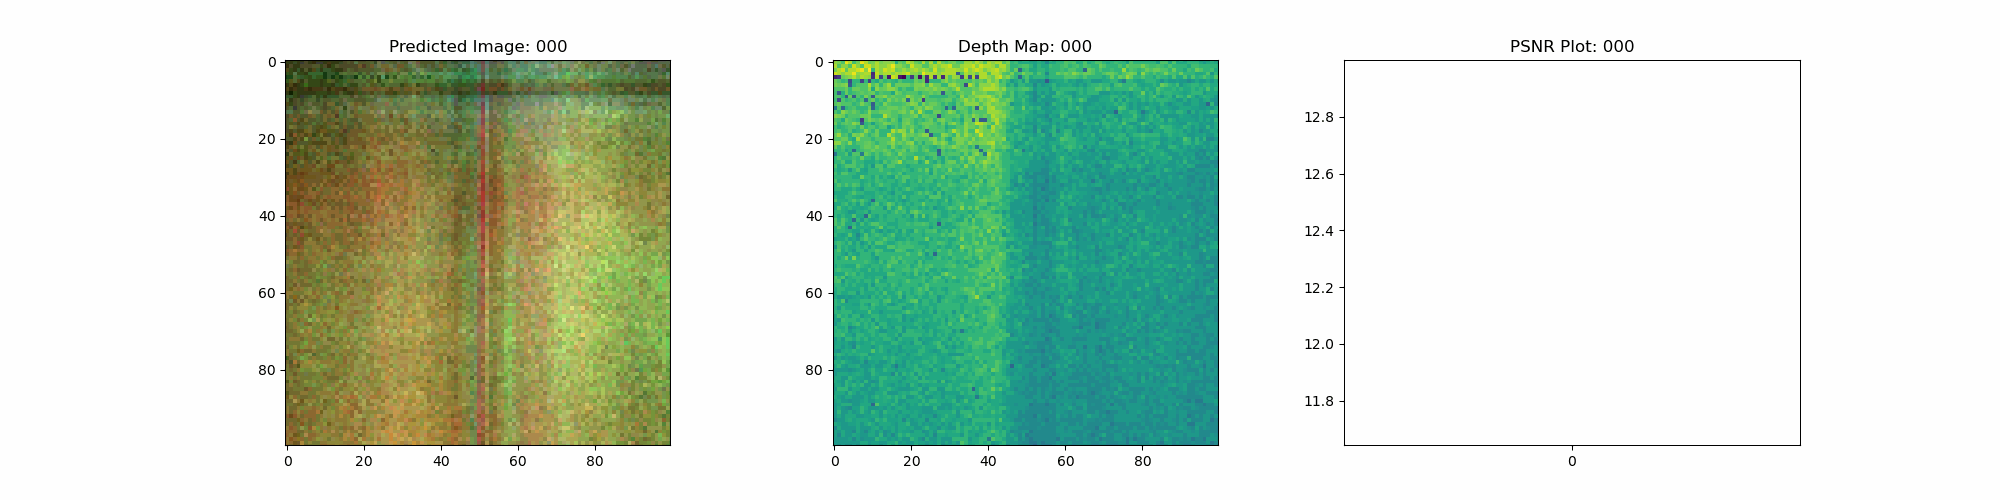

In [28]:
def show_gif(fname):
    with open(fname, 'rb') as fd:
        b64 = base64.b64encode(fd.read()).decode('ascii')
    return display.HTML(f'<img src="data:image/gif;base64,{b64}" />')

def create_gif(path_to_images, name_gif):
    if os.path.isfile(name_gif): os.remove(name_gif)
    filenames = glob.glob(path_to_images)
    filenames = sorted(filenames)
    images = []
    for filename in filenames:
        images.append(iio.imread(filename))
    images = np.stack(images, axis=0)
    iio.imwrite(name_gif, images, duration=300)


create_gif('./nerf_results/*.png', './nerf_results/training.gif')
show_gif('./nerf_results/training.gif')

## Inference

In this section, we use the trained model to synthesize novel views. The model was trained on a sparse set of views and has learned the volumetric radiance field (Section 10.2). Given a new camera pose, the model can render the corresponding 2D image by casting rays and accumulating colors via volume rendering (Section 10.5).

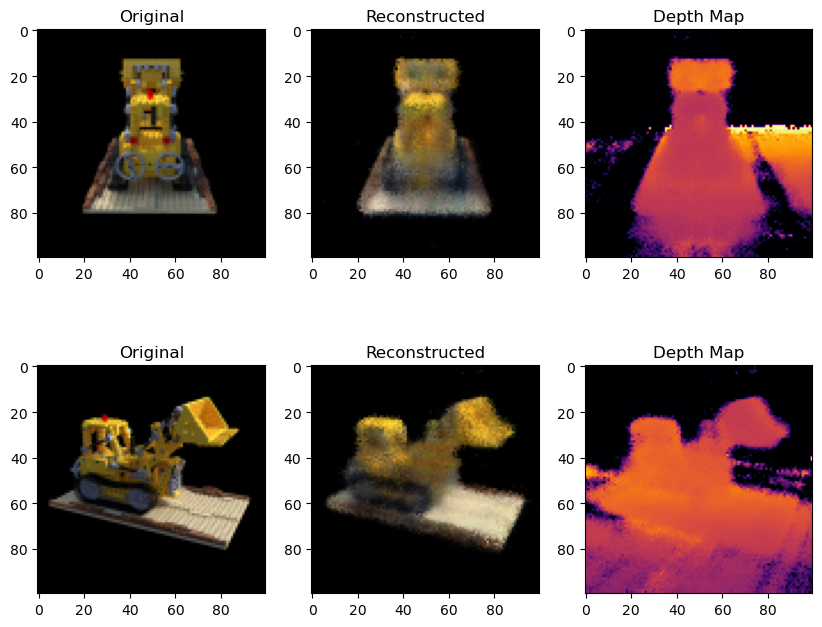

In [29]:
# Get the trained NeRF model and infer.
nerf_model = model.nerf_model
test_recons_images, depth_maps = render_rgb_depth(
    model=nerf_model,
    rays_flat=test_rays_flat,
    t_vals=test_t_vals,
    i_shape=IN_SHAPE,
    train=False,
)

# Create subplots.
fig, axes = plt.subplots(nrows=len(test_imgs), ncols=3, figsize=(10, 4*len(test_imgs)))

for ax, ori_img, recons_img, depth_map in zip(
    axes, test_imgs, test_recons_images, depth_maps
):
    ax[0].imshow(keras.utils.array_to_img(ori_img))
    ax[0].set_title('Original')

    ax[1].imshow(keras.utils.array_to_img(recons_img))
    ax[1].set_title('Reconstructed')

    ax[2].imshow(keras.utils.array_to_img(depth_map[..., None]), cmap='inferno')
    ax[2].set_title('Depth Map')

## Render 3D Scene

Here we will synthesize novel 3D views and stitch all of them together
to render a video encompassing the 360-degree view.

In [30]:
def get_translation_t(t):
    '''Get the translation matrix for movement in t.'''
    matrix = [
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, t],
        [0, 0, 0, 1],
    ]
    return tf.convert_to_tensor(matrix, dtype=tf.float32)

def get_rotation_phi(phi):
    '''Get the rotation matrix for movement in phi.'''
    matrix = [
        [1, 0, 0, 0],
        [0, tf.cos(phi), -tf.sin(phi), 0],
        [0, tf.sin(phi), tf.cos(phi), 0],
        [0, 0, 0, 1],
    ]
    return tf.convert_to_tensor(matrix, dtype=tf.float32)

def get_rotation_theta(theta):
    '''Get the rotation matrix for movement in theta.'''
    matrix = [
        [tf.cos(theta), 0, -tf.sin(theta), 0],
        [0, 1, 0, 0],
        [tf.sin(theta), 0, tf.cos(theta), 0],
        [0, 0, 0, 1],
    ]
    return tf.convert_to_tensor(matrix, dtype=tf.float32)

def pose_spherical(theta, phi, t):
    '''
    Get the camera to world matrix for the corresponding theta, phi
    and t.
    '''
    c2w = get_translation_t(t)
    c2w = get_rotation_phi(phi / 180.0 * np.pi) @ c2w
    c2w = get_rotation_theta(theta / 180.0 * np.pi) @ c2w
    c2w = np.array([[-1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]]) @ c2w
    return c2w


rgb_frames = []
batch_flat = []
batch_t = []

# Iterate over different theta value and generate scenes.
for index, theta in tqdm(enumerate(np.linspace(0.0, 360.0, 120, endpoint=False))):
    # Get the camera to world matrix.
    c2w = pose_spherical(theta, -30.0, 4.0)

    #
    ray_oris, ray_dirs = get_rays(H, W, FOCAL, c2w)
    rays_flat, dirs_flat, t_vals = render_flat_rays(
        ray_oris, ray_dirs, near=2.0, far=6.0, num_samples=NUM_SAMPLES, rand=False
    )
    rays_flat = tf.concat([rays_flat, dirs_flat], axis=-1)

    if index % BATCH_SIZE == 0 and index > 0:
        batched_flat = tf.stack(batch_flat, axis=0)
        batch_flat = [rays_flat]

        batched_t = tf.stack(batch_t, axis=0)
        batch_t = [t_vals]

        rgb, _ = render_rgb_depth(
            nerf_model, batched_flat, batched_t, i_shape=IN_SHAPE, train=False
        )

        temp_rgb = [np.clip(255 * img, 0.0, 255.0).astype(np.uint8) for img in rgb]

        rgb_frames = rgb_frames + temp_rgb
    else:
        batch_flat.append(rays_flat)
        batch_t.append(t_vals)

rgb_video = 'nerf_results/rgb_video.mp4'
if os.path.isfile(rgb_video): os.remove(rgb_video)
iio.imwrite(rgb_video, rgb_frames, fps=30, quality=7, macro_block_size=None)

120it [00:24,  4.96it/s]


### Visualize the video

Here we can see the rendered 360 degree view of the scene. The model
has successfully learned the entire volumetric space through the
sparse set of images in **only 20 epochs**. You can view the
rendered video saved locally, named `rgb_video.mp4`.

In [31]:
def show_video(video_path, video_width = 320):
  video_file = open(video_path, "r+b").read()
  video_url = f"data:video/mp4;base64,{base64.b64encode(video_file).decode()}"
  return display.HTML(f"""<video width={video_width} controls><source src="{video_url}"></video>""")

show_video('./nerf_results/rgb_video.mp4')

## Conclusion

This exercise demonstrated a minimal implementation of NeRF, covering the core pipeline components: camera ray construction (Section 10.3–10.4), positional encoding (Section 10.6), the MLP architecture (Section 10.8), and volume rendering (Section 10.5). Only the coarse network was used here; the full NeRF employs hierarchical sampling with a fine network for improved quality (Section 10.7).

## References

- Mildenhall, B. et al., "NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis," ECCV 2020. [Paper](https://arxiv.org/abs/2003.08934) | [Code](https://github.com/bmild/nerf)
- Keras NeRF example (Apache 2.0 License): [keras.io/examples/vision/nerf](https://keras.io/examples/vision/nerf/)

(c) 2026 S. W. Lee